## Refinement based on pure reweighting
to see the advantages of on-the-fly refinement

In [1]:
import os, pickle, copy
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt

In [2]:
import sys
sys.path.append('../')

from simpleMD import SimpleMD, generate_chain
# if not is_run, SimpleMD is only required to load pickles

from my_tools import compute_SAXS

In [3]:
from MDRefine import load_data, minimizer

### 1. prepare data 
from `SimpleMD` outputs (in `data` directory) to `MDRefine` (new directory `polymer`)

do it just once (the first time you run a new trajectory)

In [4]:
is_run = False
cell = (100., 100., 100.)

In [5]:
if is_run:
    positions = generate_chain(10, 1.)
    keys_prior = {
        'temperature' : 0.722,
        'tstep' : 0.001,
        'friction' : 1.0,
        'forcecutoff' : 2.5,
        'k_fene' : 30.0,
        'maxbond' : 1.5,
        'q_SAXS' : [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
        'listcutoff' : 3.0,
        'nstep' : int(1e5),
        'nconfig' : 100,
        'nstat' : 100,
        'nequilib' : 10000,
        # pass the crystal lattice generated above
        'cell' : cell,
        'positions' : positions
        }
    
    print('run MD simulation with prior knowledge')
    smd_prior = SimpleMD(**keys_prior)
    smd_prior.run()

    print('run MD simulation for ground truth (to get experimental values)')
    keys_ref = copy.deepcopy(keys_prior)
    keys_ref.update({'k_angle' : 5.0})

    smd_reference = SimpleMD(**keys_ref)
    smd_reference.run()



In [6]:
if not is_run:
    with open("../data/prior_long.pickle", "rb") as file:
        smd_prior = pickle.load(file)
    with open("../data/test_long.pickle", "rb") as file:
        smd_reference = pickle.load(file)

In [7]:
vars(smd_prior).keys()

dict_keys(['iv', 'iy', 'iset', 'gset', 'write_positions_first', 'write_statistics_first', 'write_statistics_last_time_reopened', 'write_statistics_fp', 'temperature', 'maxneighbors', 'tstep', 'friction', 'forcecutoff', 'k_fene', 'maxbond', 'k_angle', 'l_rgyr2', 'exp_rgyr2', 'k_rgyr2', 'tau_rgyr2', 'alpha_rgyr2', 'sigma_rgyr2', 'q_SAXS', 'l_SAXS', 'a_SAXS', 'b_SAXS', 'c_SAXS', 'exp_SAXS', 'k_SAXS', 'tau_SAXS', 'alpha', 'beta', 'gamma', 'sigma_SAXS', 'k_fm', 'tau_fm', 'eta_ff0', 'tau_ff', 'listcutoff', 'nstep', 'nconfig', 'nstat', 'nequilib', 'nonthefly', 'nupdate', 'idum', 'wrapatoms', 'statfile', 'trajfile', 'outputfile', 'inputfile', 'positions', 'cell', 'statfile_f', 'statistics', 'lambda_otf', 'SAXS_otf', 'fm_otf', 'trajectory', 'SAXS', 'grad_lambda', 'angle', 'output'])

In [8]:
print(len([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))]))
print(len([smd_reference.trajectory[i][1] for i in range(len(smd_reference.trajectory))]))


100000
100000


#### `forward_qs`
from `smd_prior`

quantities required to compute the observables by evaluation of the `forward_model_fun` function
- in this case, SAXS values for each frame of the trajectory, since the correction to the forward model is a linear combination of them (for each frame)

In [9]:
traj = np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))])

print('shape of traj: ', traj.shape)

shape of traj:  (100000, 10, 3)


In [10]:
smd_prior.angle[5].shape

(100000,)

they have different number of frames (angle is saved every `nstat` iterations, while the trajectory every `nconfig`)

In [11]:
saxs = []

for i in range(len(traj)):
    saxs.append(compute_SAXS(traj[i], cell, smd_prior.q_SAXS))

saxs = np.array(saxs)

In [12]:
saxs.shape

(100000, 10)

In [13]:
!mkdir ../data_MDRefine
!mkdir ../data_MDRefine/polymer
!mkdir ../data_MDRefine/polymer/forward_qs

# if not 'saxs.npy' in os.listdir('../data_MDRefine/polymer/forward_qs'):
np.save('../data_MDRefine/polymer/forward_qs/saxs_long.npy', saxs)

mkdir: impossibile creare la directory "../data_MDRefine": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer": File già esistente
mkdir: impossibile creare la directory "../data_MDRefine/polymer/forward_qs": File già esistente


In [13]:
lines = ["A,1", "B,0"]

with open("../data_MDRefine/original_fm_coeffs", "w") as f:
    for line in lines:
        f.write(line + "\n")

#### experimental values
from `smd_reference`

from a logical point of view, `exp_saxs` should be exactly given by `smd_reference.SAXS` I would say, without linear combination that should be added to the prior...

In [14]:
exp_saxs = 1.5*smd_reference.SAXS + 2.0
sigma_saxs = 1.0*np.ones(len(exp_saxs))

exp_vals = np.vstack((exp_saxs, sigma_saxs)).T

!mkdir ../data_MDRefine/polymer/g_exp
np.save('../data_MDRefine/polymer/g_exp/saxs_long.npy', exp_vals)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/g_exp": File già esistente


In [15]:
!mkdir ../data_MDRefine/polymer/names
np.save('../data_MDRefine/polymer/names/saxs.npy', np.array(smd_reference.q_SAXS).T)

mkdir: impossibile creare la directory "../data_MDRefine/polymer/names": File già esistente


In [16]:
assert (smd_reference.q_SAXS == smd_prior.q_SAXS), 'error: mismatch on q_SAXS'

### 2. load data

In [4]:
infos = {'global': {
    'path_directory': '../data_MDRefine',
    'system_names': ['polymer_longtime'],  # 'polymer' or 'polymer_longtime' for longer MD simulation
    'g_exp': ['saxs'],
    'forward_qs': ['saxs'],
    'forward_coeffs': 'original_fm_coeffs'  # np.array([1., 0.])
}}

In [5]:
def forward_model_fun(fm_coeffs, forward_qs):
    forward_qs_out = {'saxs': fm_coeffs[0]*forward_qs['saxs'] + fm_coeffs[1]}
    return forward_qs_out

infos['global']['forward_model'] = forward_model_fun

In [6]:
data = load_data(infos)

loading data from directory...
loading  polymer_longtime
done


In [7]:
if list(data.mol.keys()) == ['polymer_longtime']:
    data.mol['polymer'] = data.mol['polymer_longtime']
    del data.mol['polymer_longtime']
    data.properties.system_names = ['polymer']

In [8]:
vars(data.mol['polymer']).keys()

dict_keys(['temperature', 'gexp', 'names', 'ref', 'forward_model', 'forward_qs', 'weights', 'g', 'n_experiments', 'n_frames'])

In [9]:
data.mol['polymer'].weights.shape

(100000,)

try with different regularizations for the coefficients of the forward model

In [10]:
def forward_model_regularization(coeffs, coeffs0):
    # L2 regularization
    # regularization = (coeffs[0] - coeffs0[0])**2 + (coeffs[1] - coeffs0[1])**2
    
    # regularization used in the thesis
    regularization = jnp.log(coeffs[0])
    return regularization

regularization = {'forward_model_reg' : forward_model_regularization}

### 3. minimize the loss function
purely based on reweighting initial trajectory

In [11]:
result = minimizer(data, regularization=regularization, alpha=1, gamma=1, if_print_biblio=False)

In [12]:
vars(result)

{'loss': Array(4.81071018, dtype=float64),
 'pars': array([  1.85655656, -13.84652811]),
 'mini':   message: Desired error not necessarily achieved due to precision loss.
   success: False
    status: 2
       fun: 4.810710175890126
         x: [ 1.857e+00 -1.385e+01]
       nit: 14
       jac: [-1.476e-02 -3.059e-04]
  hess_inv: [[ 3.213e-02 -1.421e+00]
             [-1.421e+00  6.344e+01]]
      nfev: 33
      njev: 21,
 'min_lambdas': {'polymer': {'saxs': Array([ 0.12337864, -0.05327862, -0.21272639, -0.23603615, -0.0752351 ,
           0.20466159,  0.44463235,  0.45180863,  0.0780513 , -0.72556218],      dtype=float64)}},
 'minis': {'polymer':   message: Optimization terminated successfully.
    success: True
     status: 0
        fun: -4.191986713473478
          x: [ 7.178e-03 -1.204e-02 -1.031e-01 -1.906e-01 -8.764e-02
               3.126e-01  8.309e-01  9.796e-01  1.880e-01 -1.871e+00]
        nit: 5
        jac: [-1.789e-05  1.816e-04  1.609e-04 -4.497e-04 -1.426e-04
       

In [15]:
vars(result).keys()

dict_keys(['loss', 'pars', 'mini', 'min_lambdas', 'minis', 'intermediates', 'time', 'reg_fm', 'D_KL_alpha', 'abs_difference', 'av_g', 'chi2', 'logZ_new', 'weights_new'])

In [31]:
result.min_lambdas

{'polymer': {'saxs': Array([ 0.12337864, -0.05327862, -0.21272639, -0.23603615, -0.0752351 ,
          0.20466159,  0.44463235,  0.45180863,  0.0780513 , -0.72556218],      dtype=float64)}}

In [33]:
result.intermediates.lambdas.shape

(33, 10)

In [34]:
result.intermediates.lambdas[-1]

Array([ 0.00717911, -0.01204236, -0.10316378, -0.19040764, -0.08753938,
        0.31258874,  0.83054854,  0.97938642,  0.18817957, -1.87068927],      dtype=float64)

In [40]:
result.min_lambdas

{'polymer': {'saxs': Array([ 0.12337864, -0.05327862, -0.21272639, -0.23603615, -0.0752351 ,
          0.20466159,  0.44463235,  0.45180863,  0.0780513 , -0.72556218],      dtype=float64)}}

In [41]:
result.intermediates.loss

Array([703.99629292, 433.2755648 , 106.33424941,  11.51348348,
         7.67056663,   7.16522357,   6.51614246,   6.02988332,
         5.43965453,   4.99401961,   4.82948826,   4.81115469,
         4.81072246,   4.81071111,   4.81071018,   4.81071023,
         4.81071026,   4.81071027,   4.81071027,   4.81071027,
         4.81071027,   4.81071023,   4.81071027,   4.81071029,
         4.81071029,   4.81071029,   4.81071029,   4.81071029,
         4.81071029,   4.81071029,   4.81071029,   4.81071029,
         4.81071029], dtype=float64)

why `result.intermediates.lambdas[-1]` is different from `result.lambdas_min`??

`result.lambdas_min` is de-normalized

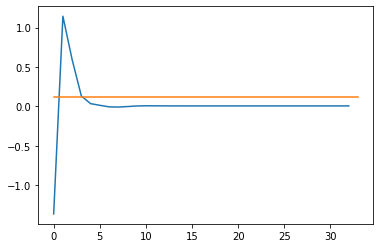

In [38]:
plt.plot(result.intermediates.lambdas[:, 0])

my_val = result.min_lambdas['polymer']['saxs'][0]

plt.plot([0, len(result.intermediates.lambdas)], my_val*np.ones(2))

In [18]:
vars(result.intermediates).keys()

dict_keys(['loss', 'pars', 'lambdas', 'minis'])

`result.intermediates.lambdas` comes from normalized observables, so to compare with on-the-fly refinement you have to denormalize them

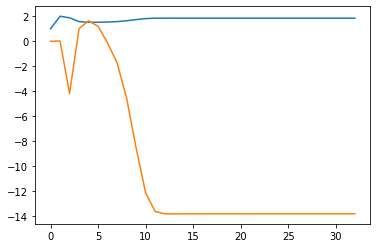

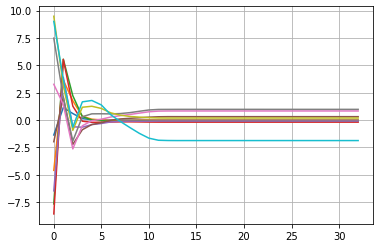

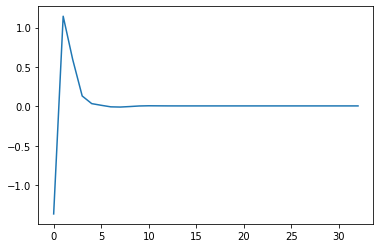

In [30]:
plt.plot(result.intermediates.pars)  # , '.')

plt.figure()
plt.plot(result.intermediates.lambdas)
plt.grid()

plt.figure()
plt.plot(result.intermediates.lambdas[:, 0])

In [101]:
new_weights = result.weights_new['polymer']

print(len(new_weights), len(smd_prior.angle[5]))

100000 100000


In [102]:
np.array([smd_prior.trajectory[i][1] for i in range(len(smd_prior.trajectory))]).shape

(100000, 10, 3)

3.6418320140558147


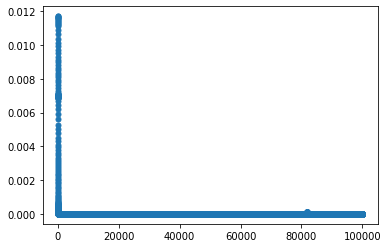

In [103]:
plt.plot(new_weights, '.')

p0 = 1/len(new_weights)
dkl = np.sum(new_weights*np.log(new_weights/p0))

print(dkl)

- checked with `shuffle`, it appears that only first frames are modified but it is just by chance

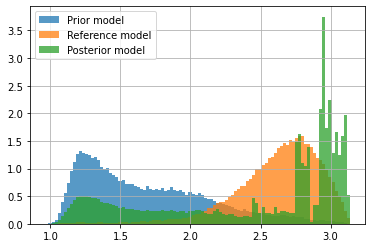

In [105]:
my_hist = {}

out = plt.hist(smd_prior.angle[3], bins=100, density=True, alpha=0.75, label='Prior model')
my_hist['prior'] = out[0]
bins = out[1]  # only in this way you can compare distributions by computing the D_KL

my_hist['reference'] = plt.hist(smd_reference.angle[3], bins=bins, density=True, alpha=0.75, label='Reference model')[0]
my_hist['reweighted'] = plt.hist(smd_prior.angle[3], weights=new_weights, bins=bins, density=True, alpha=0.75, label='Posterior model')[0]

for k in my_hist.values():
    k /= np.sum(k)

# plt.yscale('symlog')
plt.grid()
plt.legend()

In [106]:
from my_tools import compute_dkl

In [107]:
dkl1 = compute_dkl(my_hist['reweighted'], my_hist['prior'])

dkl2 = compute_dkl(my_hist['reference'], my_hist['prior'])

print(dkl1, dkl2)

1.6209580731559055 1.8645365856538847


In [108]:
print('new coefficients of the forward model: ', result.pars)

new coefficients of the forward model:  [  1.85655656 -13.84652811]


In [109]:
out_saxs = forward_model_fun(result.pars, data.mol['polymer'].forward_qs)['saxs']
out_saxs_av = np.mean(out_saxs, axis=0)
out_saxs_av2 = np.average(out_saxs, axis=0, weights=new_weights)


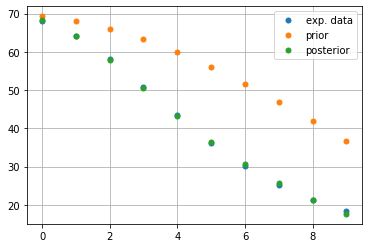

In [110]:
plt.rcParams['lines.markersize'] = 10

plt.plot(data.mol['polymer'].gexp['saxs'][:, 0], '.', label='exp. data')
plt.plot(out_saxs_av, '.', label='prior')
plt.plot(out_saxs_av2, '.', label='posterior')
plt.legend()
plt.grid()

### shuffle?
what happens?

In [32]:
arr = np.arange(len(data.mol['polymer'].weights))

np.random.shuffle(arr)

arr

array([7345, 8858, 8810, ..., 2515, 3965, 6916])

In [ ]:
data.mol['polymer'].forward_qs['saxs'] = data.mol['polymer'].forward_qs['saxs'][arr]
data.mol['polymer'].g['saxs'] = data.mol['polymer'].g['saxs'][arr]
data.mol['polymer'].weights = data.mol['polymer'].weights[arr]

I get the same result by `minimizer`, as it must be
(I was quite surprised by the plot of the new weights, since it seemed that only initial weights were modified)